Periods: 2015-12, MAE: 2.92
Periods: 2016-01, MAE: 3.09
Periods: 2016-02, MAE: 3.04
Periods: 2016-03, MAE: 2.55
Periods: 2016-04, MAE: 2.50
Periods: 2016-05, MAE: 2.19
Periods: 2016-06, MAE: 1.78
Periods: 2016-07, MAE: 1.54
Periods: 2016-08, MAE: 1.48
Periods: 2016-09, MAE: 1.60
Periods: 2016-10, MAE: 2.31
Periods: 2016-11, MAE: 2.80
Periods: 2016-12, MAE: 2.57
Periods: 2017-01, MAE: 3.36
Periods: 2017-02, MAE: 3.15
Periods: 2017-03, MAE: 2.11
Periods: 2017-04, MAE: 2.13
Periods: 2017-05, MAE: 1.71
Periods: 2017-06, MAE: 1.45
Periods: 2017-07, MAE: 1.57
Periods: 2017-08, MAE: 1.47
Periods: 2017-09, MAE: 1.58
Periods: 2017-10, MAE: 2.69
Periods: 2017-11, MAE: 2.69
Periods: 2017-12, MAE: 3.41
Periods: 2018-01, MAE: 2.88
Periods: 2018-02, MAE: 2.59
Periods: 2018-03, MAE: 3.42
Periods: 2018-04, MAE: 2.65
Periods: 2018-05, MAE: 1.54
Periods: 2018-06, MAE: 1.34
Periods: 2018-07, MAE: 1.32
Periods: 2018-08, MAE: 1.62
Periods: 2018-09, MAE: 1.71
Periods: 2018-10, MAE: 2.82
Periods: 2018-11, MA

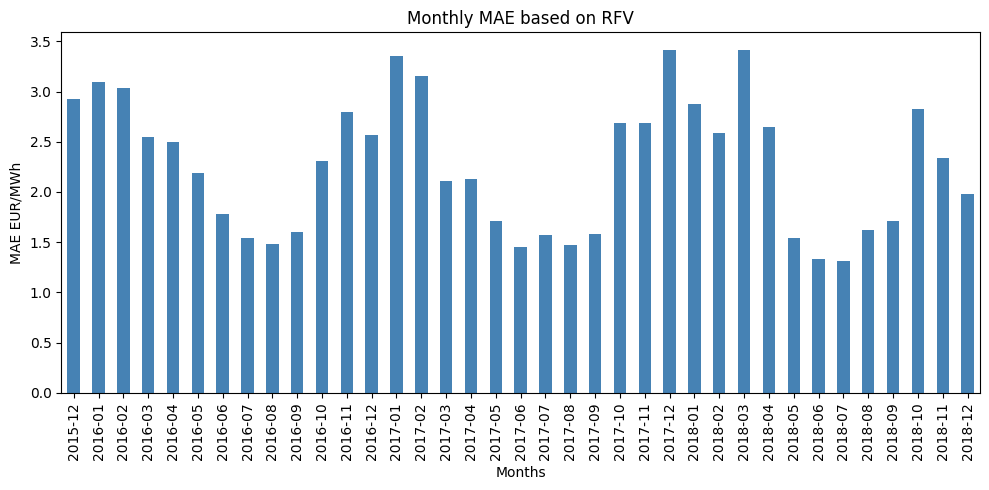

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("energy_dataset.csv")
df["time"] = pd.to_datetime(df["time"], utc = True)
df = df.set_index("time")

df["hour"] = df.index.hour
df["month"] = df.index.month
df["price_lag1"] = df["price actual"].shift(1)
df["price_lag24"] = df["price actual"].shift(24)

df["month_year"] = df.index.to_period("M") 

periods = df["month_year"].unique()

df = df[["price actual", "price_lag1", "price_lag24", "hour", "month", "month_year"]].dropna()

mae_scores = []

for i in range(12, len(periods)): 
    train = df[df["month_year"]<periods[i]]
    test = df[df["month_year"]==periods[i]]
    #print(f"Training upto: {periods[i-1]}, testing on: {periods[i]}")

    X_train = train[["price_lag1", "price_lag24", "hour", "month"]].values
    y_train = train["price actual"].values
    X_test = test[["price_lag1", "price_lag24", "hour", "month"]].values
    y_test = test["price actual"].values
    
    model = LinearRegression()
    model.fit(X_train,y_train)

    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test,y_pred)
    mae_scores.append(mae)
    print(f"Periods: {periods[i]}, MAE: {mae:.2f}")

print(f"\nAverage MAE: {np.mean(mae_scores):.2f} EUR/MWh")
print(f"Std Deviation: {np.std(mae_scores):.2f} EUR/MWh")

mae_series = pd.Series(mae_scores, index=periods[12:])

mae_series.plot(kind="bar", figsize=(10,5), color="steelblue")
plt.title("Monthly MAE based on RFV") #Rolling Forecast Validation
plt.xlabel("Months")
plt.ylabel("MAE EUR/MWh")
plt.tight_layout()
plt.show()
